# Generate Pseudo Labels

Chạy VietOCR + PaddleOCR trên toàn bộ ảnh crop để tạo pseudo-label.

**Đầu vào:** `cropped_fields.zip` trên Google Drive (mount Drive)  
**Đầu ra:** `pseudo_labels.jsonl` lưu vào Drive

Schema mỗi record:
```json
{"crop_path": "...", "class": "...", "split": "...",
 "text_vietocr": "...", "conf_vietocr": 0.0,
 "text_paddleocr": "...", "conf_paddleocr": 0.0,
 "best_text": "...", "best_conf": 0.0}
```

## 1. Cài đặt

In [1]:
!pip install vietocr easyocr -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.9/133.9 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 109.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 20.7 MB/s eta 0:00:00


## 2. Mount Drive & cấu hình đường dẫn

In [2]:
import zipfile
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

# Chỉnh đường dẫn đến file zip trong Drive
ZIP_PATH  = Path("/content/drive/MyDrive/cropped_fields.zip")  # <-- sửa nếu cần

BASE_DIR  = Path("/content")
CROPS_DIR = BASE_DIR / "cropped_fields"
OUT_DIR   = Path("/content/drive/MyDrive")   # lưu thẳng vào Drive

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(str(BASE_DIR))

manifest_path = CROPS_DIR / "manifest.jsonl"
with open(manifest_path, encoding="utf-8") as f:
    total = sum(1 for _ in f)
print(f"{total} crops")

Mounted at /content/drive
22636 crops


## 3. Load VietOCR

In [3]:
import os
import PIL._util

# Patch PIL compatibility cho vietocr
if not hasattr(PIL._util, "is_directory"):
    PIL._util.is_directory = os.path.isdir
if not hasattr(PIL._util, "is_path"):
    PIL._util.is_path = lambda f: isinstance(f, (str, bytes, os.PathLike))

import torch
from PIL import Image
from vietocr.tool.predictor import Predictor
from vietocr.tool.config import Cfg

if not hasattr(Image, "ANTIALIAS"):
    Image.ANTIALIAS = Image.LANCZOS

vietocr_cfg = Cfg.load_config_from_name("vgg_transformer")
vietocr_cfg["cnn"]["pretrained"] = True
vietocr_cfg["device"] = "cuda:0" if torch.cuda.is_available() else "cpu"

vietocr_model = Predictor(vietocr_cfg)
print(f"VietOCR loaded on {vietocr_cfg['device']}")

Downloading: "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth" to /root/.cache/torch/hub/checkpoints/vgg19_bn-c79401a0.pth


100%|██████████| 548M/548M [00:03<00:00, 175MB/s]
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(
18533it [00:12, 1469.94it/s]


VietOCR loaded on cuda:0


## 4. Load EasyOCR

In [4]:
import easyocr

easy_model = easyocr.Reader(["vi"], gpu=torch.cuda.is_available())
print(f"EasyOCR loaded")

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteEasyOCR loaded


## 5. Hàm OCR

In [5]:
def run_vietocr(img_path: str) -> tuple[str, float]:
    img = Image.open(img_path).convert("RGB")
    text, conf = vietocr_model.predict(img, return_prob=True)
    return text, float(conf)


def run_easyocr(img_path: str) -> tuple[str, float]:
    result = easy_model.readtext(img_path, detail=1)
    if not result:
        return "", 0.0
    texts = [r[1] for r in result]
    confs = [r[2] for r in result]
    return " ".join(texts), float(sum(confs) / len(confs))


def ensemble(text_v: str, conf_v: float,
             text_e: str, conf_e: float) -> tuple[str, float]:
    if text_v == text_e:
        return text_v, max(conf_v, conf_e)
    if conf_v >= conf_e:
        return text_v, conf_v
    return text_e, conf_e

## 6. Chạy OCR

In [6]:
import json
from tqdm.notebook import tqdm

with open(manifest_path, encoding="utf-8") as f:
    records = [json.loads(line) for line in f]

results = []
errors  = 0

for rec in tqdm(records, desc="OCR"):
    rel      = rec["path"].replace("\\", "/").replace("data/interim/cropped_fields/", "")
    img_path = str(CROPS_DIR / rel)

    try:
        text_v, conf_v = run_vietocr(img_path)
    except Exception:
        text_v, conf_v = "", 0.0

    try:
        text_e, conf_e = run_easyocr(img_path)
    except Exception:
        text_e, conf_e = "", 0.0

    if text_v == "" and text_e == "":
        errors += 1
        continue

    best_text, best_conf = ensemble(text_v, conf_v, text_e, conf_e)

    results.append({
        "crop_path":     rec["path"],
        "class":         rec["class"],
        "split":         rec["split"],
        "text_vietocr":  text_v,
        "conf_vietocr":  round(conf_v, 4),
        "text_easyocr":  text_e,
        "conf_easyocr":  round(conf_e, 4),
        "best_text":     best_text,
        "best_conf":     round(best_conf, 4),
    })

print(f"Xong: {len(results)} results, {errors} errors")

OCR:   0%|          | 0/22636 [00:00<?, ?it/s]

Xong: 22636 results, 0 errors


In [7]:
# for r in results[:5]:
#     print(f"[{r['class']}]")
#     print(f"  vietocr : {r['text_vietocr']!r} ({r['conf_vietocr']})")
#     print(f"  easyocr : {r['text_easyocr']!r} ({r['conf_easyocr']})")
#     print(f"  best    : {r['best_text']!r}")
#     print()


## 7. Thống kê

High   (>= 0.9):  9889 (43.7%)
Medium (0.5-0.9):  9914 (43.8%)
Low    (< 0.5):   2833 (12.5%)

Conf TB theo class:
  id        : 0.9263
  name      : 0.8982
  birth     : 0.8701
  origin    : 0.6091
  address   : 0.5614
  title     : 0.8695

VietOCR == EasyOCR: 2634/22636 (11.6%)


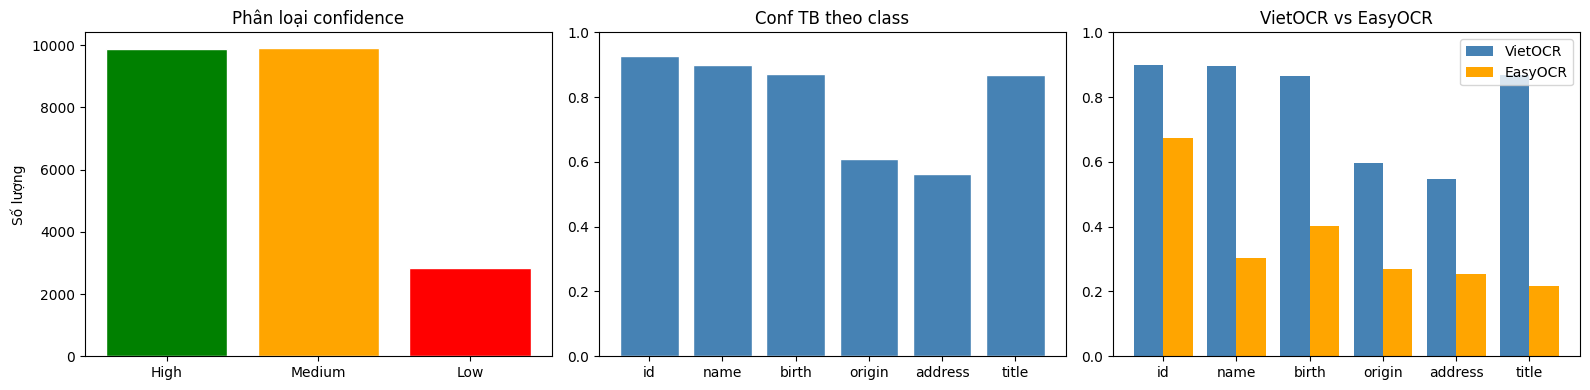

In [8]:
import numpy as np
import matplotlib.pyplot as plt

FIELD_CLASSES = ["id", "name", "birth", "origin", "address", "title"]

high   = [r for r in results if r["best_conf"] >= 0.9]
medium = [r for r in results if 0.5 <= r["best_conf"] < 0.9]
low    = [r for r in results if r["best_conf"] < 0.5]

print(f"High   (>= 0.9): {len(high):5d} ({len(high)/len(results)*100:.1f}%)")
print(f"Medium (0.5-0.9): {len(medium):5d} ({len(medium)/len(results)*100:.1f}%)")
print(f"Low    (< 0.5):  {len(low):5d} ({len(low)/len(results)*100:.1f}%)")

print("\nConf TB theo class:")
class_avg = {}
for cls in FIELD_CLASSES:
    confs = [r["best_conf"] for r in results if r["class"] == cls]
    avg = np.mean(confs) if confs else 0
    class_avg[cls] = avg
    print(f"  {cls:10s}: {avg:.4f}")

agree = sum(1 for r in results if r["text_vietocr"] == r["text_easyocr"])
print(f"\nVietOCR == EasyOCR: {agree}/{len(results)} ({agree/len(results)*100:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(["High", "Medium", "Low"], [len(high), len(medium), len(low)],
            color=["green", "orange", "red"], edgecolor="white")
axes[0].set_title("Phân loại confidence")
axes[0].set_ylabel("Số lượng")

axes[1].bar(FIELD_CLASSES, [class_avg[c] for c in FIELD_CLASSES],
            color="steelblue", edgecolor="white")
axes[1].set_title("Conf TB theo class")
axes[1].set_ylim(0, 1)

viet_avg = [np.mean([r["conf_vietocr"] for r in results if r["class"] == c]) for c in FIELD_CLASSES]
easy_avg = [np.mean([r["conf_easyocr"] for r in results if r["class"] == c]) for c in FIELD_CLASSES]
x = range(len(FIELD_CLASSES))
axes[2].bar([i - 0.2 for i in x], viet_avg, width=0.4, label="VietOCR", color="steelblue")
axes[2].bar([i + 0.2 for i in x], easy_avg, width=0.4, label="EasyOCR", color="orange")
axes[2].set_title("VietOCR vs EasyOCR")
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(FIELD_CLASSES)
axes[2].set_ylim(0, 1)
axes[2].legend()

plt.tight_layout()
plt.show()

## 8. Lưu & tải về

In [9]:
import json

out_path = OUT_DIR / "pseudo_labels.jsonl"
with open(out_path, "w", encoding="utf-8") as f:
    for rec in results:
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

print(f"Saved: {out_path} ({len(results)} records)")

Saved: /content/drive/MyDrive/pseudo_labels.jsonl (22636 records)
